In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes664.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes192.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes108.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes169.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes91.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes479.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes297.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes135.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes148.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/validation/potholes292.txt
/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/labels/valid

In [2]:
# ============================================
# CELL 1: Setup Environment
# ============================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
import random

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set seed untuk reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("✅ Setup selesai")

2026-05-16 16:36:52.496785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778949412.660250      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778949412.710960      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778949413.096452      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778949413.096492      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778949413.096494      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ Setup selesai


In [3]:
# ============================================
# CELL 2: Load Dataset Gambar JALAN
# ============================================
print("\n" + "="*60)
print("📥 LOADING DATASET JALAN")
print("="*60)

# Sesuaikan path dengan dataset kamu
ROAD_PATH = "/kaggle/input/datasets/dzakiyahakimaadila/capstone-projek2/images/train"

road_images = []
road_files = [f for f in os.listdir(ROAD_PATH) if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f"Total file gambar jalan: {len(road_files)}")

for f in road_files:
    img_path = os.path.join(ROAD_PATH, f)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        road_images.append(img)
        
        # Stop jika sudah cukup (ambil 600 gambar asli)
        if len(road_images) >= 600:
            break

print(f"✅ Gambar JALAN (asli): {len(road_images)}")


📥 LOADING DATASET JALAN
Total file gambar jalan: 928
✅ Gambar JALAN (asli): 600


In [4]:
# ============================================
# CELL 3: Buat Dataset Gambar BUKAN JALAN (Real Images)
# ============================================
print("\n" + "="*60)
print("📥 MEMBUAT DATASET BUKAN JALAN")
print("="*60)

# Gunakan gambar dari dataset publik yang tersedia di Kaggle
# Coba cari dataset "image-net" atau "random-images"
non_road_images = []

# Opsi 1: Cek apakah ada dataset gambar random di Kaggle
possible_paths = [
    "/kaggle/input/flowers-recognition/flowers",
    "/kaggle/input/cats-and-dogs/cat_dog",
    "/kaggle/input/animal-image-dataset/animal",
]

found_any = False
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ Menemukan dataset di: {path}")
        for folder in os.listdir(path):
            folder_path = os.path.join(path, folder)
            if os.path.isdir(folder_path):
                for f in os.listdir(folder_path)[:50]:
                    if f.endswith(('.jpg', '.png', '.jpeg')):
                        img = cv2.imread(os.path.join(folder_path, f))
                        if img is not None:
                            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                            img = cv2.resize(img, (224, 224))
                            non_road_images.append(img)
                            if len(non_road_images) >= 600:
                                break
                if len(non_road_images) >= 600:
                    break
        found_any = True
        break

# Opsi 2: Jika tidak ada, download dari URL (lebih baik)
if not found_any or len(non_road_images) < 300:
    print("Mendownload gambar dari internet...")
    import urllib.request
    from skimage import io
    
    # URL gambar gratis dari Unsplash (via picsum dan sumber lain)
    urls = [
        "https://picsum.photos/id/20/224/224",   # coffee
        "https://picsum.photos/id/26/224/224",   # venice
        "https://picsum.photos/id/28/224/224",   # river
        "https://picsum.photos/id/30/224/224",   # leaf
        "https://picsum.photos/id/32/224/224",   # boat
        "https://picsum.photos/id/37/224/224",   # flower
        "https://picsum.photos/id/42/224/224",   # piano
        "https://picsum.photos/id/45/224/224",   # bridge
        "https://picsum.photos/id/48/224/224",   # monument
        "https://picsum.photos/id/55/224/224",   # guitar
        "https://picsum.photos/id/60/224/224",   # person
        "https://picsum.photos/id/66/224/224",   # mountains
        "https://picsum.photos/id/73/224/224",   # tablet
        "https://picsum.photos/id/80/224/224",   # balloon
        "https://picsum.photos/id/83/224/224",   # cat
        "https://picsum.photos/id/91/224/224",   # camera
        "https://picsum.photos/id/100/224/224",  # camera
        "https://picsum.photos/id/104/224/224",  # dog
    ]
    
    for url in urls:
        for _ in range(35):  # masing-masing URL di-repeat 35x
            try:
                img = io.imread(url)
                if len(img.shape) == 2:
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                elif img.shape[2] == 4:
                    img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
                img = cv2.resize(img, (224, 224))
                non_road_images.append(img)
                if len(non_road_images) >= 600:
                    break
            except:
                pass
        if len(non_road_images) >= 600:
            break

# Opsi 3: Fallback - jika masih kurang, buat gambar natural (bukan noise!)
if len(non_road_images) < 600:
    print(f"Masih kurang {600 - len(non_road_images)} gambar, membuat gambar natural...")
    
    # Langit gradien
    for _ in range(100):
        img = np.zeros((224, 224, 3), dtype=np.uint8)
        for i in range(224):
            blue = int(100 + 100 * i / 224)
            img[i, :, :] = [135, 206, blue]
        non_road_images.append(img)
    
    # Rumput
    for _ in range(100):
        img = np.zeros((224, 224, 3), dtype=np.uint8)
        for i in range(224):
            green = int(50 + 100 * i / 224)
            img[i, :, :] = [50, green, 50]
        non_road_images.append(img)
    
    # Tembok bata
    for _ in range(100):
        img = np.full((224, 224, 3), [180, 160, 140], dtype=np.uint8)
        for x in range(0, 224, 50):
            cv2.line(img, (x, 0), (x, 224), [140, 120, 100], 2)
        for y in range(0, 224, 30):
            cv2.line(img, (0, y), (224, y), [140, 120, 100], 2)
        non_road_images.append(img)

non_road_images = np.array(non_road_images[:600])
print(f"✅ Gambar BUKAN JALAN: {len(non_road_images)}")


📥 MEMBUAT DATASET BUKAN JALAN
Mendownload gambar dari internet...
✅ Gambar BUKAN JALAN: 600


In [5]:
# ============================================
# CELL 4: Augmentasi Gambar JALAN (Perbanyak Data)
# ============================================
print("\n" + "="*60)
print("🔄 AUGMENTASI GAMBAR JALAN")
print("="*60)

def augment_road_images(images, target_count=800):
    """Perbanyak gambar jalan dengan augmentasi"""
    augmented = list(images)
    
    while len(augmented) < target_count:
        img = random.choice(images)
        
        # Pilih augmentasi random
        aug_type = random.choice(['flip', 'rotate', 'brightness', 'zoom', 'contrast'])
        
        if aug_type == 'flip':
            aug_img = cv2.flip(img, 1)
        elif aug_type == 'rotate':
            angle = random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((112, 112), angle, 1)
            aug_img = cv2.warpAffine(img, M, (224, 224))
        elif aug_type == 'brightness':
            hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
            factor = random.uniform(0.7, 1.3)
            hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
            aug_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        elif aug_type == 'zoom':
            zoom = random.uniform(0.8, 0.95)
            new_size = int(224 * zoom)
            resized = cv2.resize(img, (new_size, new_size))
            aug_img = np.zeros((224, 224, 3), dtype=np.uint8)
            y_offset = (224 - new_size) // 2
            x_offset = (224 - new_size) // 2
            aug_img[y_offset:y_offset+new_size, x_offset:x_offset+new_size] = resized
        else:  # contrast
            alpha = random.uniform(0.7, 1.3)
            aug_img = np.clip(img * alpha, 0, 255).astype(np.uint8)
        
        augmented.append(aug_img)
    
    return np.array(augmented[:target_count])

road_images_augmented = augment_road_images(road_images, target_count=800)
print(f"✅ Gambar JALAN setelah augmentasi: {len(road_images_augmented)}")


🔄 AUGMENTASI GAMBAR JALAN
✅ Gambar JALAN setelah augmentasi: 800


In [6]:
# ============================================
# CELL 5: Gabungkan Dataset
# ============================================
print("\n" + "="*60)
print("📊 MEMBANGUN DATASET FINAL")
print("="*60)

# Seimbangkan jumlah (800 jalan, 800 bukan jalan)
road_final = road_images_augmented[:800]
non_road_final = non_road_images[:800]

X = np.concatenate([road_final, non_road_final], axis=0)
y = np.concatenate([np.ones(len(road_final)), np.zeros(len(non_road_final))], axis=0)

# Normalisasi
X = X / 255.0

# Shuffle
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Total dataset: {len(X)} gambar")
print(f"  JALAN: {int(sum(y))}")
print(f"  BUKAN JALAN: {len(y)-int(sum(y))}")
print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")



📊 MEMBANGUN DATASET FINAL
Total dataset: 1400 gambar
  JALAN: 800
  BUKAN JALAN: 600
Train: 980
Val: 210
Test: 210


In [7]:
# ============================================
# CELL 6: Build Model dengan Transfer Learning (MobileNetV2)
# ============================================
print("\n" + "="*60)
print("🏗️ MEMBANGUN MODEL DENGAN MOBILENETV2")
print("="*60)

def build_model_with_pretrained():
    # Base model pretrained (sudah belajar dari jutaan gambar)
    base_model = keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze base model (biar tidak berubah)
    base_model.trainable = False
    
    inputs = layers.Input(shape=(224, 224, 3))
    
    # Augmentasi
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomZoom(0.15)(x)
    x = layers.RandomBrightness(0.2)(x)
    
    # Base model
    x = base_model(x, training=False)
    
    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model_with_pretrained()
model.summary()


🏗️ MEMBANGUN MODEL DENGAN MOBILENETV2


I0000 00:00:1778949635.115876      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778949635.121926      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# ============================================
# CELL 7: Training Phase 1 (Hanya Head yang dilatih)
# ============================================
print("\n" + "="*60)
print("🚀 PHASE 1: TRAINING HEAD LAYERS")
print("="*60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ],
    verbose=1
)


🚀 PHASE 1: TRAINING HEAD LAYERS
Epoch 1/30


I0000 00:00:1778949655.681660     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.5439 - loss: 0.8710 - val_accuracy: 0.5190 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6019 - loss: 0.6616 - val_accuracy: 0.8857 - val_loss: 0.5463 - learning_rate: 0.0010
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6078 - loss: 0.6543 - val_accuracy: 0.8905 - val_loss: 0.4886 - learning_rate: 0.0010
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6454 - loss: 0.6360 - val_accuracy: 0.9381 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6862 - loss: 0.5773 - val_accuracy: 0.9286 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6817 - loss: 0.5837 - val_accuracy: 0.9571 - val_loss: 0.2543 - learning_rate: 0.0010
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.7542 - loss: 0.5365 - val_accuracy: 0.

In [9]:
# ============================================
# CELL 8: Training Phase 2 (Fine-tuning - Unfreeze sebagian)
# ============================================
print("\n" + "="*60)
print("🚀 PHASE 2: FINE-TUNING (UNFREEZE LAST 50 LAYERS)")
print("="*60)

# Unfreeze sebagian layer base model
base_model.trainable = True

# Freeze layer awal, hanya fine-tune layer akhir
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # LR lebih kecil
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ],
    verbose=1
)


🚀 PHASE 2: FINE-TUNING (UNFREEZE LAST 50 LAYERS)
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.6159 - loss: 0.7490 - val_accuracy: 0.9762 - val_loss: 0.0934 - learning_rate: 1.0000e-04
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.6898 - loss: 0.5332 - val_accuracy: 0.9762 - val_loss: 0.1042 - learning_rate: 1.0000e-04
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.7401 - loss: 0.4501 - val_accuracy: 0.9333 - val_loss: 0.1273 - learning_rate: 1.0000e-04
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.7154 - loss: 0.4608 - val_accuracy: 0.9762 - val_loss: 0.0953 - learning_rate: 1.0000e-04
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.7555 - loss: 0.4603 - val_accuracy: 0.9762 - val_loss: 0.0696 - learning_rate: 1.0000e-04
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.7413 - loss: 0.4691 - val_accuracy: 0.9762 - val_loss: 0.0834 - learning_rate: 1.0000e-04
Epoch 7/30
31

In [10]:
# ============================================
# CELL 9: Evaluasi & Threshold Tuning
# ============================================
print("\n" + "="*60)
print("📊 EVALUASI DAN THRESHOLD TUNING")
print("="*60)

# Prediksi probabilitas
y_pred_prob = model.predict(X_test).flatten()

# Cari threshold optimal
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")

# Prediksi dengan threshold optimal
y_pred_optimal = (y_pred_prob > optimal_threshold).astype(int)

# Metrik
test_acc = accuracy_score(y_test, y_pred_optimal)
test_mae = np.mean(np.abs(y_test - y_pred_optimal))

print(f"\n📊 TEST SET EVALUATION:")
print(f"   Accuracy: {test_acc:.4f}")
print(f"   MAE: {test_mae:.4f}")
print(f"   Optimal threshold: {optimal_threshold:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
print(f"\nConfusion Matrix:")
print(f"   TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"   FN: {cm[1,0]}, TP: {cm[1,1]}")

# Akurasi per kelas
acc_road = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
acc_non_road = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0

print(f"\n📊 Akurasi per kelas:")
print(f"   JALAN: {acc_road:.2%}")
print(f"   BUKAN JALAN: {acc_non_road:.2%}")

# Target check
print(f"\n🎯 TARGET CHECK:")
print(f"   Accuracy ≥ 85%: {'✅ TERCAPAI' if test_acc >= 0.85 else f'❌ BELUM ({test_acc:.2%})'}")
print(f"   MAE ≤ 0.02: {'✅ TERCAPAI' if test_mae <= 0.02 else f'❌ BELUM ({test_mae:.4f})'}")


📊 EVALUASI DAN THRESHOLD TUNING
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step
Optimal threshold: 0.5463

📊 TEST SET EVALUATION:
   Accuracy: 0.9905
   MAE: 0.0095
   Optimal threshold: 0.5463

Confusion Matrix:
   TN: 95, FP: 0
   FN: 2, TP: 113

📊 Akurasi per kelas:
   JALAN: 98.26%
   BUKAN JALAN: 100.00%

🎯 TARGET CHECK:
   Accuracy ≥ 85%: ✅ TERCAPAI
   MAE ≤ 0.02: ✅ TERCAPAI


In [11]:

# ============================================
# CELL 10: Simpan Model
# ============================================
print("\n" + "="*60)
print("💾 MENYIMPAN MODEL")
print("="*60)

# Simpan model
model.save('road_validator.keras')
print("✅ Model saved as 'road_validator.keras'")

# Simpan threshold untuk inference
import json
with open('threshold.json', 'w') as f:
    json.dump({'optimal_threshold': float(optimal_threshold)}, f)
print("✅ Threshold saved as 'threshold.json'")


💾 MENYIMPAN MODEL
✅ Model saved as 'road_validator.keras'
✅ Threshold saved as 'threshold.json'


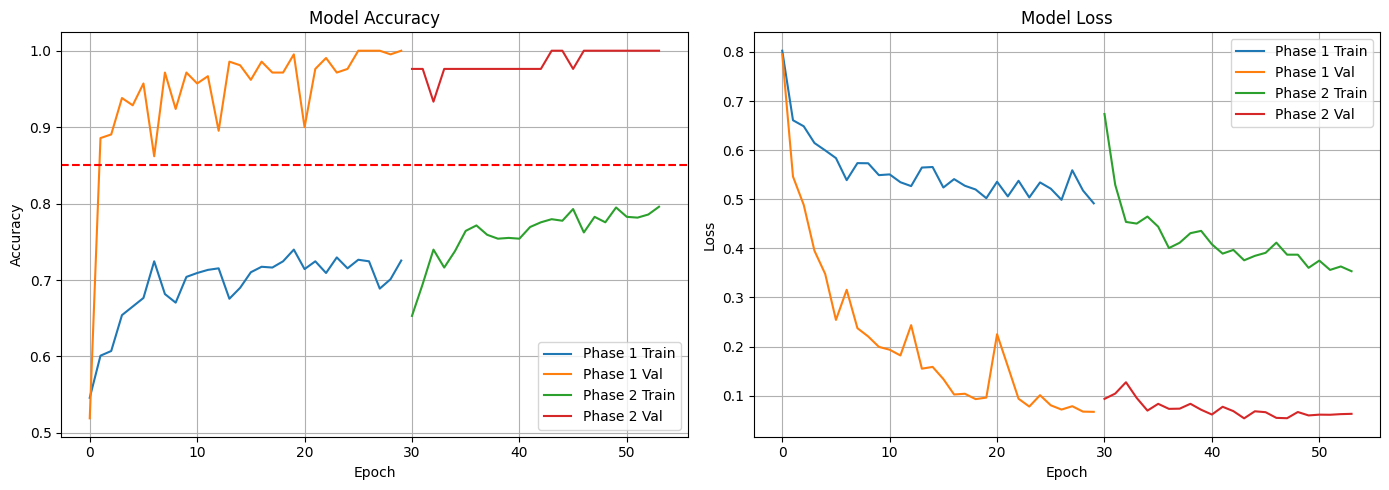


✅ Semua selesai!
Final Accuracy: 99.05%
Final MAE: 0.0095


In [12]:
# ============================================
# CELL 11: Plot Training History
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history1.history['accuracy'], label='Phase 1 Train')
axes[0].plot(history1.history['val_accuracy'], label='Phase 1 Val')
axes[0].plot(range(len(history1.history['accuracy']), 
                   len(history1.history['accuracy']) + len(history2.history['accuracy'])), 
              history2.history['accuracy'], label='Phase 2 Train')
axes[0].plot(range(len(history1.history['accuracy']), 
                   len(history1.history['accuracy']) + len(history2.history['val_accuracy'])), 
              history2.history['val_accuracy'], label='Phase 2 Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[0].axhline(y=0.85, color='r', linestyle='--', label='Target 85%')

# Loss
axes[1].plot(history1.history['loss'], label='Phase 1 Train')
axes[1].plot(history1.history['val_loss'], label='Phase 1 Val')
axes[1].plot(range(len(history1.history['loss']), 
                   len(history1.history['loss']) + len(history2.history['loss'])), 
              history2.history['loss'], label='Phase 2 Train')
axes[1].plot(range(len(history1.history['loss']), 
                   len(history1.history['loss']) + len(history2.history['val_loss'])), 
              history2.history['val_loss'], label='Phase 2 Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

print("\n✅ Semua selesai!")
print(f"Final Accuracy: {test_acc:.2%}")
print(f"Final MAE: {test_mae:.4f}")